<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/U5MR_Malawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [265]:
import pandas as pd

file_path = '/content/U5MR_Malawi_renam.dta'
df = pd.read_stata(file_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,case_identification,birth_column_number,country_code_phase,cluster_number,household_number,year_interview,respondent_age,age_5yr_groups,primary_sampling_unit,region,type_residence,type_residence_alt,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,education_attainment,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_pregnancy_wanted,current_contraceptive_method,contraceptive_use_intention,wanted_last_child,wanted_last_pregnancy,preg_postnatal_entries,weight_kg,height_cm,marital_status,birth_order,child_is_twin,sex_child,child_alive,preceding_birth_interval,breastfeeding_duration,antenatal_visits,place_delivery,birth_weight_kg,when_put_to_breast,child_health_check,bmi_sd
0,1 1 1,1,MW8,1,1,2024,48,45-49,1,northern,rural,rural,primary,tube well or borehole,30,pit latrine with slab,0,complete primary,not at all,less than once a week,not at all,middle,6,1,13,NaN,not using,non-user - intends to use later,wanted no more,wanted no more,1,NaN,NaN,married,6,single birth,male,no,244.0,never breastfed,4.0,government hospital,3500.0,NaN,no,NaN
1,1 9 1,1,MW8,1,9,2024,27,25-29,1,northern,rural,rural,primary,tube well or borehole,10,pit latrine with slab,1,incomplete primary,not at all,not at all,not at all,poorer,4,1,14,NaN,injections,using modern method,NaN,NaN,0,677.0,1759.0,widowed,4,single birth,female,yes,36.0,NaN,NaN,NaN,NaN,NaN,NaN,53.0
2,1 16 2,1,MW8,1,16,2024,24,20-24,1,northern,rural,rural,primary,tube well or borehole,20,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,middle,3,2,17,NaN,injections,using modern method,wanted then,wanted then,1,NaN,NaN,married,3,single birth,female,yes,29.0,still breastfeeding,3.0,government hospital,2000.0,within first hour,yes,NaN
3,1 16 2,2,MW8,1,16,2024,24,20-24,1,northern,rural,rural,primary,tube well or borehole,20,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,middle,3,2,17,NaN,injections,using modern method,wanted then,wanted then,1,NaN,NaN,married,2,single birth,male,yes,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 24 2,1,MW8,1,24,2024,40,40-44,1,northern,rural,rural,primary,tube well or borehole,30,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,richer,8,2,18,NaN,injections,using modern method,wanted no more,wanted no more,1,579.0,1483.0,married,8,single birth,female,yes,22.0,"ever breastfed, not currently breastfeeding",4.0,government hospital,2500.0,within first hour,yes,40.0


In [266]:
missing_percentage = df.isnull().sum() * 100 / len(df)
missing_percentage = missing_percentage.sort_values(ascending=False)
print("Percentage of missing values per variable:")
print(missing_percentage[missing_percentage > 0])

Percentage of missing values per variable:
current_pregnancy_wanted    95.029240
bmi_sd                      55.774854
height_cm                   48.351202
weight_kg                   48.351202
child_health_check          42.283951
antenatal_visits            42.283951
when_put_to_breast          42.024042
place_delivery              39.221897
birth_weight_kg             39.221897
breastfeeding_duration      39.221897
preceding_birth_interval    32.724172
wanted_last_child           28.906758
wanted_last_pregnancy       27.997076
wealth_index                 4.418454
dtype: float64


In [267]:
print(f"Original DataFrame shape: {df.shape}")

# Get columns with more than 30% missing values
columns_to_drop = missing_percentage[missing_percentage > 30].index.tolist()

# Drop these columns from the DataFrame
df = df.drop(columns=columns_to_drop)

print(f"Columns dropped: {columns_to_drop}")
print(f"New DataFrame shape: {df.shape}")

print("\nUpdated DataFrame head:")
df.head()

Original DataFrame shape: (12312, 46)
Columns dropped: ['current_pregnancy_wanted', 'bmi_sd', 'height_cm', 'weight_kg', 'child_health_check', 'antenatal_visits', 'when_put_to_breast', 'place_delivery', 'birth_weight_kg', 'breastfeeding_duration', 'preceding_birth_interval']
New DataFrame shape: (12312, 35)

Updated DataFrame head:


,case_identification,birth_column_number,country_code_phase,cluster_number,household_number,year_interview,respondent_age,age_5yr_groups,primary_sampling_unit,region,type_residence,type_residence_alt,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,education_attainment,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,contraceptive_use_intention,wanted_last_child,wanted_last_pregnancy,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive
0,1 1 1,1,MW8,1,1,2024,48,45-49,1,northern,rural,rural,primary,tube well or borehole,30,pit latrine with slab,0,complete primary,not at all,less than once a week,not at all,middle,6,1,13,not using,non-user - intends to use later,wanted no more,wanted no more,1,married,6,single birth,male,no
1,1 9 1,1,MW8,1,9,2024,27,25-29,1,northern,rural,rural,primary,tube well or borehole,10,pit latrine with slab,1,incomplete primary,not at all,not at all,not at all,poorer,4,1,14,injections,using modern method,NaN,NaN,0,widowed,4,single birth,female,yes
2,1 16 2,1,MW8,1,16,2024,24,20-24,1,northern,rural,rural,primary,tube well or borehole,20,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,middle,3,2,17,injections,using modern method,wanted then,wanted then,1,married,3,single birth,female,yes
3,1 16 2,2,MW8,1,16,2024,24,20-24,1,northern,rural,rural,primary,tube well or borehole,20,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,middle,3,2,17,injections,using modern method,wanted then,wanted then,1,married,2,single birth,male,yes
4,1 24 2,1,MW8,1,24,2024,40,40-44,1,northern,rural,rural,primary,tube well or borehole,30,pit latrine with slab,2,incomplete primary,not at all,not at all,not at all,richer,8,2,18,injections,using modern method,wanted no more,wanted no more,1,married,8,single birth,female,yes


In [268]:
print(df.columns.tolist())

['case_identification', 'birth_column_number', 'country_code_phase', 'cluster_number', 'household_number', 'year_interview', 'respondent_age', 'age_5yr_groups', 'primary_sampling_unit', 'region', 'type_residence', 'type_residence_alt', 'education_level', 'type_water_source', 'time_toget_water', 'toilet_type', 'num_children_under5', 'education_attainment', 'freq_read_news', 'freq_radio', 'freq_tv', 'wealth_index', 'total_children_ever_born', 'births_last5yrs', 'age_at_first_birth', 'current_contraceptive_method', 'contraceptive_use_intention', 'wanted_last_child', 'wanted_last_pregnancy', 'preg_postnatal_entries', 'marital_status', 'birth_order', 'child_is_twin', 'sex_child', 'child_alive']


In [269]:
selected_columns = [
    'respondent_age', 'age_5yr_groups','region', 'type_residence', 'education_level',
    'type_water_source', 'time_toget_water', 'toilet_type',
    'num_children_under5', 'freq_read_news', 'freq_radio', 'freq_tv',
    'wealth_index', 'total_children_ever_born', 'births_last5yrs',
    'age_at_first_birth', 'current_contraceptive_method',
    'wanted_last_child', 'preg_postnatal_entries', 'marital_status',
    'birth_order', 'child_is_twin', 'sex_child', 'child_alive'
]
df_selected = df[selected_columns]

print("Selected DataFrame head:")
df_selected.head()

Selected DataFrame head:


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes


In [270]:
child_alive_counts = df_selected['child_alive'].value_counts()
child_alive_percentage = df_selected['child_alive'].value_counts(normalize=True) * 100

print("Counts and percentages for 'child_alive':")
print(pd.DataFrame({'Count': child_alive_counts, 'Percentage': child_alive_percentage.round(2).astype(str) + '%'}))

Counts and percentages for 'child_alive':
             Count Percentage
child_alive                  
yes          11875     96.45%
no             437      3.55%


In [271]:
print("Summary statistics for 'respondent_age':")
print(df_selected['respondent_age'].describe())

Summary statistics for 'respondent_age':
count    12312.000000
mean        27.920565
std          7.062391
min         15.000000
25%         22.000000
50%         27.000000
75%         33.000000
max         49.000000
Name: respondent_age, dtype: float64


In [272]:
# Perform Min-Max Scaling on respondent_age
age_min = df_selected['respondent_age'].min()
age_max = df_selected['respondent_age'].max()

# Using .loc to avoid SettingWithCopyWarning
df_selected.loc[:, 'respondent_age_scaled'] = (df_selected['respondent_age'] - age_min) / (age_max - age_min)

print("Min-Max Scaling completed for 'respondent_age'.")
print("\nUpdated DataFrame with scaled column:")
df_selected.head()

Min-Max Scaling completed for 'respondent_age'.

Updated DataFrame with scaled column:


/tmp/ipykernel_8223/2883468300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected.loc[:, 'respondent_age_scaled'] = (df_selected['respondent_age'] - age_min) / (age_max - age_min)


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294


In [273]:
water_source_counts = df_selected['type_water_source'].value_counts()
water_source_percentage = df_selected['type_water_source'].value_counts(normalize=True) * 100

print("Counts and percentages for 'type_water_source':")
print(pd.DataFrame({
    'Count': water_source_counts,
    'Percentage': water_source_percentage.round(2).astype(str) + '%'
}))

Counts and percentages for 'type_water_source':
                                                    Count Percentage
type_water_source                                                   
tube well or borehole                                7673     62.32%
public tap/standpipe                                 1115      9.06%
piped to yard/plot                                    994      8.07%
unprotected well                                      707      5.74%
piped to neighbor                                     461      3.74%
protected well                                        412      3.35%
river/dam/lake/ponds/stream/canal/irrigation ch...    362      2.94%
piped into dwelling                                   279      2.27%
unprotected spring                                    159      1.29%
not a dejure resident                                 105      0.85%
protected spring                                       32      0.26%
bottled water                                          

In [274]:
# Define categories
improved = [
    "tube well or borehole",
    "public tap/standpipe",
    "piped to yard/plot",
    "piped to neighbor",
    "protected well",
    "piped into dwelling",
    "protected spring",
    "bottled water"
]

# Normalize text first
df_selected = df_selected.copy()
df_selected['type_water_source'] = df_selected['type_water_source'].str.strip().str.lower()

# Create binary variable
df_selected['water_source_category'] = df_selected['type_water_source'].apply(
    lambda x: "Improved" if x in improved else "Unimproved"
)

# Summary
cat_counts = df_selected['water_source_category'].value_counts()
cat_pct = df_selected['water_source_category'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': cat_counts,
    'Percentage': cat_pct.round(2).astype(str) + '%'
}))

print("\nUpdated DataFrame head with water_source_category:")
df_selected.head()

                       Count Percentage
water_source_category                  
Improved               10975     89.14%
Unimproved              1337     10.86%

Updated DataFrame head with water_source_category:


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled,water_source_category
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588,Improved
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941,Improved
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706,Improved
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706,Improved
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294,Improved


In [275]:
print("Counts for 'time_toget_water':")
print(df_selected['time_toget_water'].value_counts(dropna=False))

Counts for 'time_toget_water':
time_toget_water
on premises    2495
10             1908
30             1621
20             1331
60             1085
               ... 
440               1
560               1
588               1
580               1
720               1
Name: count, Length: 87, dtype: int64


In [276]:
df_selected = df_selected.copy()

def categorize_time_to_get_water(time_val):
    if pd.isna(time_val):
        return time_val # Keep NaN as NaN
    if isinstance(time_val, str):
        time_val_lower = time_val.lower().strip()
        if time_val_lower == 'on premises':
            return 'on_premises'

    try:
        numeric_time = float(time_val)
        if numeric_time == 0:
            return 'on_premises'
        elif 0 < numeric_time <= 30:
            return '≤30_minutes'
        elif numeric_time > 30:
            return '>30_minutes'
        else:
            return pd.NA # For any other numeric values not explicitly covered
    except (ValueError, TypeError):
        return pd.NA # For other non-numeric strings or unparseable values

# Apply the function to create the new categorical column
df_selected['time_to_get_water_category'] = df_selected['time_toget_water'].apply(categorize_time_to_get_water)

print("\nCounts and percentages for 'time_to_get_water_category':")
print(df_selected['time_to_get_water_category'].value_counts(dropna=False))

print("\nUpdated DataFrame head with time_to_get_water_category:")
df_selected.head()


Counts and percentages for 'time_to_get_water_category':
time_to_get_water_category
≤30_minutes    7233
on_premises    2496
>30_minutes    2432
<NA>            151
Name: count, dtype: int64

Updated DataFrame head with time_to_get_water_category:


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled,water_source_category,time_to_get_water_category
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588,Improved,≤30_minutes
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941,Improved,≤30_minutes
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706,Improved,≤30_minutes
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706,Improved,≤30_minutes
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294,Improved,≤30_minutes


In [277]:
toilet_type_counts = df_selected['toilet_type'].value_counts()
toilet_type_percentage = df_selected['toilet_type'].value_counts(normalize=True) * 100

print("Counts and percentages for 'toilet_type':")
print(pd.DataFrame({
    'Count': toilet_type_counts,
    'Percentage': toilet_type_percentage.round(2).astype(str) + '%'
}))

Counts and percentages for 'toilet_type':
                                       Count Percentage
toilet_type                                            
pit latrine with slab                   5851     47.52%
pit latrine without slab/open pit       2718     22.08%
pit latrine with log/rock               2199     17.86%
no facility/bush/field                   712      5.78%
ventilated improved pit latrine (vip)    300      2.44%
flush to septic tank                     260      2.11%
not a dejure resident                    105      0.85%
flush to pit latrine                      69      0.56%
other                                     45      0.37%
flush to piped sewer system               31      0.25%
flush to somewhere else                    7      0.06%
hanging toilet/latrine                     7      0.06%
composting toilet                          5      0.04%
bucket toilet                              3      0.02%


In [278]:
# Define categories for improved and unimproved toilet types
improved_toilet_types = [
    "pit latrine with slab",
    "ventilated improved pit latrine (vip)",
    "flush to septic tank",
    "flush to pit latrine",
    "flush to piped sewer system",
    "composting toilet"
]

# Assign categories: everything not improved → Unimproved
df_selected['toilet_type_category'] = df_selected['toilet_type'].str.lower().apply(
    lambda x: "Improved" if x in improved_toilet_types else "Unimproved"
)

# Summary
tcat_counts = df_selected['toilet_type_category'].value_counts()
tcat_pct = df_selected['toilet_type_category'].value_counts(normalize=True) * 100

print("Counts and percentages for 'toilet_type_category':")
print(pd.DataFrame({
    'Count': tcat_counts,
    'Percentage': tcat_pct.round(2).astype(str) + '%'
}))

print("\nUpdated DataFrame head with toilet_type_category:")
df_selected.head()

Counts and percentages for 'toilet_type_category':
                      Count Percentage
toilet_type_category                  
Improved               6516     52.92%
Unimproved             5796     47.08%

Updated DataFrame head with toilet_type_category:


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled,water_source_category,time_to_get_water_category,toilet_type_category
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588,Improved,≤30_minutes,Improved
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941,Improved,≤30_minutes,Improved
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706,Improved,≤30_minutes,Improved
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706,Improved,≤30_minutes,Improved
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294,Improved,≤30_minutes,Improved


In [279]:
def categorize_children(num):
    if pd.isna(num):
        return num
    elif num == 0:
        return '0'
    elif 1 <= num <= 2:
        return '1-2'
    elif num >= 3:
        return '3+'
    else:
        return 'Other'

df_selected['num_children_under5_category'] = df_selected['num_children_under5'].apply(categorize_children)

print("Counts and percentages for 'num_children_under5_category':")
print(df_selected['num_children_under5_category'].value_counts(dropna=False))

print("\nUpdated DataFrame head with num_children_under5_category:")
df_selected.head()

Counts and percentages for 'num_children_under5_category':
num_children_under5_category
1-2    10980
3+       791
0        541
Name: count, dtype: int64

Updated DataFrame head with num_children_under5_category:


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled,water_source_category,time_to_get_water_category,toilet_type_category,num_children_under5_category
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588,Improved,≤30_minutes,Improved,0
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941,Improved,≤30_minutes,Improved,1-2
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706,Improved,≤30_minutes,Improved,1-2
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706,Improved,≤30_minutes,Improved,1-2
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294,Improved,≤30_minutes,Improved,1-2


In [280]:
pd.set_option('display.max_columns', None)
print(df_selected.head().to_markdown(index=False))

|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under5_category   |
|-----------------:|:-----------------|:---------|:-----------------|:------------------|:----------------------|-------------------:|:----------------------|----------------------:|:-----------------|:----------------------|:-----------|:---------------|---------------------------:|------------------:|---------------------:|:-------------------------------|:-----

In [281]:
df_selected['is_twin_category'] = df_selected['child_is_twin'].apply(lambda x: 'No' if x == 'single birth' else 'Yes')

print("Counts and percentages for 'is_twin_category':")
print(df_selected['is_twin_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nUpdated DataFrame head with 'is_twin_category':")
print(df_selected.head().to_markdown(index=False))

Counts and percentages for 'is_twin_category':
is_twin_category
No     96.32%
Yes     3.68%
Name: proportion, dtype: object

Updated DataFrame head with 'is_twin_category':
|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under5_category   | is_twin_category   |
|-----------------:|:-----------------|:---------|:-----------------|:------------------|:----------------------|-------------------:|:----------------------|--------------

In [282]:
wealth_index_counts = df_selected['wealth_index'].value_counts()
wealth_index_percentage = df_selected['wealth_index'].value_counts(normalize=True) * 100

print("Counts and percentages for 'wealth_index':")
print(pd.DataFrame({
    'Count': wealth_index_counts,
    'Percentage': wealth_index_percentage.round(2).astype(str) + '%'
}).to_markdown())

Counts and percentages for 'wealth_index':
| wealth_index   |   Count | Percentage   |
|:---------------|--------:|:-------------|
| poorest        |    2642 | 22.45%       |
| richest        |    2602 | 22.11%       |
| richer         |    2258 | 19.19%       |
| middle         |    2147 | 18.24%       |
| poorer         |    2119 | 18.01%       |


In [283]:
def categorize_births(num_births):
    if pd.isna(num_births):
        return num_births
    elif num_births == 0:
        return '0'
    elif 1 <= num_births <= 2:
        return '1-2'
    elif 3 <= num_births <= 4:
        return '3-4'
    elif num_births >= 5:
        return '5+'
    else:
        return 'Other'

df_selected['total_children_ever_born_category'] = df_selected['total_children_ever_born'].apply(categorize_births)

print("\nCounts and percentages for 'total_children_ever_born_category':")
print(df_selected['total_children_ever_born_category'].value_counts(dropna=False).to_markdown())

print("\nUpdated DataFrame head with 'total_children_ever_born_category':")
pd.set_option('display.max_columns', None)
print(df_selected.head().to_markdown(index=False))


Counts and percentages for 'total_children_ever_born_category':
| total_children_ever_born_category   |   count |
|:------------------------------------|--------:|
| 1-2                                 |    6480 |
| 3-4                                 |    3479 |
| 5+                                  |    2353 |

Updated DataFrame head with 'total_children_ever_born_category':
|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under

In [284]:
print("Summary statistics for 'age_at_first_birth':")
print(df_selected['age_at_first_birth'].describe())

Summary statistics for 'age_at_first_birth':
count    12312.000000
mean        18.780945
std          3.032869
min         10.000000
25%         17.000000
50%         18.000000
75%         20.000000
max         42.000000
Name: age_at_first_birth, dtype: float64


In [285]:
def categorize_age_first_birth(age):
    if pd.isna(age):
        return age
    if age < 18:
        return '<18'
    elif 18 <= age <= 19:
        return '18-19'
    elif 20 <= age <= 24:
        return '20-24'
    else:
        return '25+'

df_selected['age_at_first_birth_category'] = df_selected['age_at_first_birth'].apply(categorize_age_first_birth)

# Calculate counts and percentages
age_counts = df_selected['age_at_first_birth_category'].value_counts().sort_index()
age_pct = df_selected['age_at_first_birth_category'].value_counts(normalize=True).mul(100).round(2).sort_index()

print("Counts and percentages for 'age_at_first_birth_category':")
display(pd.DataFrame({'Count': age_counts, 'Percentage': age_pct.astype(str) + '%'}))

print("\nUpdated DataFrame with the new category (first 5 rows):")
pd.set_option('display.max_columns', None)
display(df_selected.head())

Counts and percentages for 'age_at_first_birth_category':


,Count,Percentage
age_at_first_birth_category,,
18-19,3876,31.48%
20-24,3521,28.6%
25+,570,4.63%
<18,4345,35.29%



Updated DataFrame with the new category (first 5 rows):


,respondent_age,age_5yr_groups,region,type_residence,education_level,type_water_source,time_toget_water,toilet_type,num_children_under5,freq_read_news,freq_radio,freq_tv,wealth_index,total_children_ever_born,births_last5yrs,age_at_first_birth,current_contraceptive_method,wanted_last_child,preg_postnatal_entries,marital_status,birth_order,child_is_twin,sex_child,child_alive,respondent_age_scaled,water_source_category,time_to_get_water_category,toilet_type_category,num_children_under5_category,is_twin_category,total_children_ever_born_category,age_at_first_birth_category
0,48,45-49,northern,rural,primary,tube well or borehole,30,pit latrine with slab,0,not at all,less than once a week,not at all,middle,6,1,13,not using,wanted no more,1,married,6,single birth,male,no,0.970588,Improved,≤30_minutes,Improved,0,No,5+,<18
1,27,25-29,northern,rural,primary,tube well or borehole,10,pit latrine with slab,1,not at all,not at all,not at all,poorer,4,1,14,injections,NaN,0,widowed,4,single birth,female,yes,0.352941,Improved,≤30_minutes,Improved,1-2,No,3-4,<18
2,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,3,single birth,female,yes,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18
3,24,20-24,northern,rural,primary,tube well or borehole,20,pit latrine with slab,2,not at all,not at all,not at all,middle,3,2,17,injections,wanted then,1,married,2,single birth,male,yes,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18
4,40,40-44,northern,rural,primary,tube well or borehole,30,pit latrine with slab,2,not at all,not at all,not at all,richer,8,2,18,injections,wanted no more,1,married,8,single birth,female,yes,0.735294,Improved,≤30_minutes,Improved,1-2,No,5+,18-19


In [286]:
import numpy as np

df_selected['contraceptive_use_binary'] = np.where(
    df_selected['current_contraceptive_method'] == 'not using', 'No', 'Yes'
)

contraceptive_binary_counts = df_selected['contraceptive_use_binary'].value_counts(dropna=False)
contraceptive_binary_percentage = df_selected['contraceptive_use_binary'].value_counts(normalize=True, dropna=False) * 100

print("Counts and percentages for 'contraceptive_use_binary':")
print(pd.DataFrame({
    'Count': contraceptive_binary_counts,
    'Percentage': contraceptive_binary_percentage.round(2).astype(str) + '%'
}).to_markdown())

print("\nUpdated DataFrame head with 'contraceptive_use_binary':")
pd.set_option('display.max_columns', None)
print(df_selected.head().to_markdown(index=False))

Counts and percentages for 'contraceptive_use_binary':
| contraceptive_use_binary   |   Count | Percentage   |
|:---------------------------|--------:|:-------------|
| Yes                        |    8406 | 68.27%       |
| No                         |    3906 | 31.73%       |

Updated DataFrame head with 'contraceptive_use_binary':
|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under5_category   | is_twin_category   | total_chi

In [287]:
wanted_last_child_counts = df_selected['wanted_last_child'].value_counts(dropna=False)
wanted_last_child_percentage = df_selected['wanted_last_child'].value_counts(normalize=True, dropna=False) * 100

print("Counts and percentages for 'wanted_last_child':")
print(pd.DataFrame({
    'Count': wanted_last_child_counts,
    'Percentage': wanted_last_child_percentage.round(2).astype(str) + '%'
}).to_markdown())

Counts and percentages for 'wanted_last_child':
| wanted_last_child   |   Count | Percentage   |
|:--------------------|--------:|:-------------|
| wanted then         |    5318 | 43.19%       |
| nan                 |    3559 | 28.91%       |
| wanted later        |    2609 | 21.19%       |
| wanted no more      |     826 | 6.71%        |


In [288]:
def categorize_marital_status(status):
    if pd.isna(status):
        return status
    status = status.lower().strip()
    if status == 'married':
        return 'Married'
    elif status == 'living with partner':
        return 'Living with partner'
    elif status in ['widowed', 'divorced']:
        return 'Divorced/Widowed'
    elif status == 'no longer living together/separated':
        return 'Separated'
    elif status in ['never in union', 'nullified']:
        return 'Never in union'
    else:
        return 'Other'

df_selected['marital_status_category'] = df_selected['marital_status'].apply(categorize_marital_status)

marital_category_counts = df_selected['marital_status_category'].value_counts(dropna=False)
marital_category_percentage = df_selected['marital_status_category'].value_counts(normalize=True, dropna=False) * 100

print("Counts and percentages for 'marital_status_category':")
print(pd.DataFrame({
    'Count': marital_category_counts,
    'Percentage': marital_category_percentage.round(2).astype(str) + '%'
}).to_markdown())

print("\nUpdated DataFrame head with 'marital_status_category':")
pd.set_option('display.max_columns', None)
print(df_selected.head().to_markdown(index=False))

Counts and percentages for 'marital_status_category':
| marital_status_category   |   Count | Percentage   |
|:--------------------------|--------:|:-------------|
| Married                   |    8596 | 69.82%       |
| Divorced/Widowed          |    1077 | 8.75%        |
| Separated                 |     999 | 8.11%        |
| Living with partner       |     936 | 7.6%         |
| Never in union            |     704 | 5.72%        |

Updated DataFrame head with 'marital_status_category':
|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent

In [289]:
def categorize_birth_order(order):
    if pd.isna(order):
        return order
    if order == 1:
        return '1'
    elif 2 <= order <= 4:
        return '2–4'
    elif order >= 5:
        return '5+'
    else:
        return 'Other'

df_selected['birth_order_category'] = df_selected['birth_order'].apply(categorize_birth_order)

# Calculate counts and percentages for the new category
birth_order_category_counts = df_selected['birth_order_category'].value_counts(dropna=False).sort_index()
birth_order_category_percentage = df_selected['birth_order_category'].value_counts(normalize=True, dropna=False).mul(100).round(2).sort_index()

print("Counts and percentages for 'birth_order_category':")
print(pd.DataFrame({
    'Count': birth_order_category_counts,
    'Percentage': birth_order_category_percentage.astype(str) + '%'
}).to_markdown())

print("\nUpdated DataFrame head with 'birth_order_category':")
pd.set_option('display.max_columns', None)
print(df_selected.head().to_markdown(index=False))

Counts and percentages for 'birth_order_category':
| birth_order_category   |   Count | Percentage   |
|:-----------------------|--------:|:-------------|
| 1                      |    3981 | 32.33%       |
| 2–4                    |    6201 | 50.37%       |
| 5+                     |    2130 | 17.3%        |

Updated DataFrame head with 'birth_order_category':
|   respondent_age | age_5yr_groups   | region   | type_residence   | education_level   | type_water_source     |   time_toget_water | toilet_type           |   num_children_under5 | freq_read_news   | freq_radio            | freq_tv    | wealth_index   |   total_children_ever_born |   births_last5yrs |   age_at_first_birth | current_contraceptive_method   | wanted_last_child   |   preg_postnatal_entries | marital_status   |   birth_order | child_is_twin   | sex_child   | child_alive   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under5_category   | is

In [290]:
df_selected.columns

Index(['respondent_age', 'age_5yr_groups', 'region', 'type_residence',
       'education_level', 'type_water_source', 'time_toget_water',
       'toilet_type', 'num_children_under5', 'freq_read_news', 'freq_radio',
       'freq_tv', 'wealth_index', 'total_children_ever_born',
       'births_last5yrs', 'age_at_first_birth', 'current_contraceptive_method',
       'wanted_last_child', 'preg_postnatal_entries', 'marital_status',
       'birth_order', 'child_is_twin', 'sex_child', 'child_alive',
       'respondent_age_scaled', 'water_source_category',
       'time_to_get_water_category', 'toilet_type_category',
       'num_children_under5_category', 'is_twin_category',
       'total_children_ever_born_category', 'age_at_first_birth_category',
       'contraceptive_use_binary', 'marital_status_category',
       'birth_order_category'],
      dtype='object')

In [291]:
final_columns = [
    'age_5yr_groups', 'region', 'type_residence',
    'education_level', 'wealth_index', 'sex_child',
    'respondent_age_scaled', 'water_source_category',
    'time_to_get_water_category', 'toilet_type_category',
    'num_children_under5_category', 'is_twin_category',
    'total_children_ever_born_category', 'age_at_first_birth_category',
    'contraceptive_use_binary', 'marital_status_category',
    'birth_order_category', 'child_alive'
]

df_final = df_selected[final_columns]

print("New DataFrame with selected columns:")
pd.set_option('display.max_columns', None)
print(df_final.head().to_markdown(index=False))

New DataFrame with selected columns:
| age_5yr_groups   | region   | type_residence   | education_level   | wealth_index   | sex_child   |   respondent_age_scaled | water_source_category   | time_to_get_water_category   | toilet_type_category   | num_children_under5_category   | is_twin_category   | total_children_ever_born_category   | age_at_first_birth_category   | contraceptive_use_binary   | marital_status_category   | birth_order_category   | child_alive   |
|:-----------------|:---------|:-----------------|:------------------|:---------------|:------------|------------------------:|:------------------------|:-----------------------------|:-----------------------|:-------------------------------|:-------------------|:------------------------------------|:------------------------------|:---------------------------|:--------------------------|:-----------------------|:--------------|
| 45-49            | northern | rural            | primary           | middle         | male       

In [292]:
df_final.shape

(12312, 18)

In [293]:
missing_percentage_final = df_final.isnull().sum() * 100 / len(df_final)
missing_percentage_final = missing_percentage_final.sort_values(ascending=False)
print("Percentage of missing values per variable in df_final:")
print(missing_percentage_final[missing_percentage_final > 0].to_markdown())

Percentage of missing values per variable in df_final:
|                            |       0 |
|:---------------------------|--------:|
| wealth_index               | 4.41845 |
| time_to_get_water_category | 1.22645 |


In [294]:
wealth_index_mode = df_final['wealth_index'].mode()[0]
time_to_get_water_category_mode = df_final['time_to_get_water_category'].mode()[0]

df_final['wealth_index'].fillna(wealth_index_mode, inplace=True)
df_final['time_to_get_water_category'].fillna(time_to_get_water_category_mode, inplace=True)

print("Missing values after imputation:")
print(df_final.isnull().sum().to_markdown())

Missing values after imputation:
|                                   |   0 |
|:----------------------------------|----:|
| age_5yr_groups                    |   0 |
| region                            |   0 |
| type_residence                    |   0 |
| education_level                   |   0 |
| wealth_index                      |   0 |
| sex_child                         |   0 |
| respondent_age_scaled             |   0 |
| water_source_category             |   0 |
| time_to_get_water_category        |   0 |
| toilet_type_category              |   0 |
| num_children_under5_category      |   0 |
| is_twin_category                  |   0 |
| total_children_ever_born_category |   0 |
| age_at_first_birth_category       |   0 |
| contraceptive_use_binary          |   0 |
| marital_status_category           |   0 |
| birth_order_category              |   0 |
| child_alive                       |   0 |


/tmp/ipykernel_8223/132725250.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['wealth_index'].fillna(wealth_index_mode, inplace=True)
/tmp/ipykernel_8223/132725250.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['wealth_index'].fillna(wealth_index_mode, inplace=True)
/tmp/ipykernel_8223/132725250.py:5: FutureWarning: 

In [295]:
df_final.head()

,age_5yr_groups,region,type_residence,education_level,wealth_index,sex_child,respondent_age_scaled,water_source_category,time_to_get_water_category,toilet_type_category,num_children_under5_category,is_twin_category,total_children_ever_born_category,age_at_first_birth_category,contraceptive_use_binary,marital_status_category,birth_order_category,child_alive
0,45-49,northern,rural,primary,middle,male,0.970588,Improved,≤30_minutes,Improved,0,No,5+,<18,No,Married,5+,no
1,25-29,northern,rural,primary,poorer,female,0.352941,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Divorced/Widowed,2–4,yes
2,20-24,northern,rural,primary,middle,female,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Married,2–4,yes
3,20-24,northern,rural,primary,middle,male,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Married,2–4,yes
4,40-44,northern,rural,primary,richer,female,0.735294,Improved,≤30_minutes,Improved,1-2,No,5+,18-19,Yes,Married,5+,yes


In [296]:
rename_dict = {
    'age_5yr_groups': 'mother_age_group_5yr',
    'region': 'region',
    'type_residence': 'residence_type',
    'education_level': 'education_level',
    'wealth_index': 'wealth_index',
    'wanted_last_child': 'wanted_birth',
    'sex_child': 'child_sex',
    'respondent_age_scaled': 'mother_age_scaled',
    'water_source_category': 'water_source_type',
    'time_to_get_water_category': 'water_access_time',
    'toilet_type_category': 'toilet_type',
    'num_children_under5_category': 'hh_num_under5_children',
    'is_twin_category': 'multiple_birth',
    'total_children_ever_born_category': 'parity',
    'age_at_first_birth_category': 'age_first_birth',
    'contraceptive_use_binary': 'contraceptive_use',
    'marital_status_category': 'marital_status',
    'birth_order_category': 'birth_order',
    'child_alive': 'child_survival_status'
}

# Filter the rename_dict to only include columns present in df_final
filtered_rename_dict = {k: v for k, v in rename_dict.items() if k in df_final.columns}

# Apply the filtered renaming to df_final
df_final.rename(columns=filtered_rename_dict, inplace=True)

print("DataFrame after renaming:")
pd.set_option('display.max_columns', None)
print(df_final.head().to_markdown(index=False))

DataFrame after renaming:
| mother_age_group_5yr   | region   | residence_type   | education_level   | wealth_index   | child_sex   |   mother_age_scaled | water_source_type   | water_access_time   | toilet_type   | hh_num_under5_children   | multiple_birth   | parity   | age_first_birth   | contraceptive_use   | marital_status   | birth_order   | child_survival_status   |
|:-----------------------|:---------|:-----------------|:------------------|:---------------|:------------|--------------------:|:--------------------|:--------------------|:--------------|:-------------------------|:-----------------|:---------|:------------------|:--------------------|:-----------------|:--------------|:------------------------|
| 45-49                  | northern | rural            | primary           | middle         | male        |            0.970588 | Improved            | ≤30_minutes         | Improved      | 0                        | No               | 5+       | <18               | No     

/tmp/ipykernel_8223/607418898.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.rename(columns=filtered_rename_dict, inplace=True)


In [297]:
#rename category of child_survival_status No as Dead and Yes as Alive
df_final['child_survival_status'] = df_final['child_survival_status'].replace({'no': 'Dead', 'yes': 'Alive'})
df_final.head()

/tmp/ipykernel_8223/2029910827.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_final['child_survival_status'] = df_final['child_survival_status'].replace({'no': 'Dead', 'yes': 'Alive'})
/tmp/ipykernel_8223/2029910827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['child_survival_status'] = df_final['child_survival_status'].replace({'no': 'Dead', 'yes': 'Alive'})


,mother_age_group_5yr,region,residence_type,education_level,wealth_index,child_sex,mother_age_scaled,water_source_type,water_access_time,toilet_type,hh_num_under5_children,multiple_birth,parity,age_first_birth,contraceptive_use,marital_status,birth_order,child_survival_status
0,45-49,northern,rural,primary,middle,male,0.970588,Improved,≤30_minutes,Improved,0,No,5+,<18,No,Married,5+,Dead
1,25-29,northern,rural,primary,poorer,female,0.352941,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Divorced/Widowed,2–4,Alive
2,20-24,northern,rural,primary,middle,female,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Married,2–4,Alive
3,20-24,northern,rural,primary,middle,male,0.264706,Improved,≤30_minutes,Improved,1-2,No,3-4,<18,Yes,Married,2–4,Alive
4,40-44,northern,rural,primary,richer,female,0.735294,Improved,≤30_minutes,Improved,1-2,No,5+,18-19,Yes,Married,5+,Alive


In [298]:
child_survival_counts = df_final['child_survival_status'].value_counts()
child_survival_percentage = df_final['child_survival_status'].value_counts(normalize=True) * 100

print("Counts and percentages for 'child_survival_status':")
print(pd.DataFrame({'Count': child_survival_counts, 'Percentage': child_survival_percentage.round(2).astype(str) + '%'}))

Counts and percentages for 'child_survival_status':
                       Count Percentage
child_survival_status                  
Alive                  11875     96.45%
Dead                     437      3.55%


In [299]:
df_final.columns.to_list()

['mother_age_group_5yr',
 'region',
 'residence_type',
 'education_level',
 'wealth_index',
 'child_sex',
 'mother_age_scaled',
 'water_source_type',
 'water_access_time',
 'toilet_type',
 'hh_num_under5_children',
 'multiple_birth',
 'parity',
 'age_first_birth',
 'contraceptive_use',
 'marital_status',
 'birth_order',
 'child_survival_status']

In [300]:
import pandas as pd

# Variables list
variables = [
    'mother_age_group_5yr', 'region', 'residence_type',
    'education_level', 'wealth_index', 'child_sex',
    'water_source_type', 'water_access_time', 'toilet_type',
    'hh_num_under5_children', 'multiple_birth', 'parity',
    'age_first_birth', 'contraceptive_use', 'marital_status',
    'birth_order'
]

# Clean outcome variable
df_final['child_survival_status'] = (
    df_final['child_survival_status']
    .astype(str).str.strip().str.lower()
)

def create_table(df, var, outcome='child_survival_status'):
    # Crosstab counts
    ct = pd.crosstab(df[var], df[outcome])

    # Ensure both categories exist
    for col in ['alive', 'dead']:
        if col not in ct.columns:
            ct[col] = 0

    # Reorder columns correctly
    ct = ct[['alive', 'dead']]

    # Rename columns for presentation
    ct = ct.rename(columns={'alive': 'Alive', 'dead': 'Dead'})

    # Convert to string counts only
    formatted = ct.astype(int).astype(str)

    # Reset index
    formatted = formatted.reset_index().rename(columns={var: 'Category'})

    # Add variable column
    formatted.insert(0, 'Variable', var)

    return formatted

# Combine all variables
final_table = pd.concat(
    [create_table(df_final, var) for var in variables],
    ignore_index=True
)

# Display
print(final_table)

# Save to Excel
final_table.to_excel("formal_table_child_survival.xlsx", index=False)

/tmp/ipykernel_8223/347586883.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['child_survival_status'] = (


child_survival_status                Variable             Category  Alive Dead
0                        mother_age_group_5yr                15-19   1047   52
1                        mother_age_group_5yr                20-24   3614  145
2                        mother_age_group_5yr                25-29   2765   63
3                        mother_age_group_5yr                30-34   2109   84
4                        mother_age_group_5yr                35-39   1447   51
5                        mother_age_group_5yr                40-44    712   30
6                        mother_age_group_5yr                45-49    181   12
7                                      region             northern   2381   69
8                                      region              central   4134  147
9                                      region             southern   5360  221
10                             residence_type                urban   2253   81
11                             residence_type       

In [301]:
print("Columns in df_final and their unique categories (for categorical variables):")
for column in df_final.columns:
    if df_final[column].dtype == 'object' or df_final[column].dtype == 'category':
        print(f"\nColumn: {column}")
        print(f"Categories: {df_final[column].unique().tolist()}")
    else:
        print(f"\nColumn: {column} (Numerical, Dtype: {df_final[column].dtype})")

Columns in df_final and their unique categories (for categorical variables):

Column: mother_age_group_5yr
Categories: ['45-49', '25-29', '20-24', '40-44', '15-19', '30-34', '35-39']

Column: region
Categories: ['northern', 'central', 'southern']

Column: residence_type
Categories: ['rural', 'urban']

Column: education_level
Categories: ['primary', 'secondary', 'no education', 'higher']

Column: wealth_index
Categories: ['middle', 'poorer', 'richer', 'poorest', 'richest']

Column: child_sex
Categories: ['male', 'female']

Column: mother_age_scaled (Numerical, Dtype: float64)

Column: water_source_type
Categories: ['Improved', 'Unimproved']

Column: water_access_time
Categories: ['≤30_minutes', 'on_premises', '>30_minutes']

Column: toilet_type
Categories: ['Improved', 'Unimproved']

Column: hh_num_under5_children
Categories: ['0', '1-2', '3+']

Column: multiple_birth
Categories: ['No', 'Yes']

Column: parity
Categories: ['5+', '3-4', '1-2']

Column: age_first_birth
Categories: ['<18', 

In [302]:
import pandas as pd

# ===============================
# FULL ENCODING PIPELINE (NOMINAL → ORDINAL)
# ===============================

# 1. Binary Encoding
binary_mapping = {
    'residence_type': {'rural': 0, 'urban': 1},
    'child_sex': {'female': 0, 'male': 1},
    'water_source_type': {'Unimproved': 0, 'Improved': 1},
    'toilet_type': {'Unimproved': 0, 'Improved': 1},
    'multiple_birth': {'No': 0, 'Yes': 1},
    'contraceptive_use': {'No': 0, 'Yes': 1},
    'child_survival_status': {'alive': 0, 'dead': 1}
}

for col, mapping in binary_mapping.items():
    if col in df_final.columns:
        df_final[col] = df_final[col].map(mapping)


# 2. Ordinal Encoding
# (excluding mother_age_group_5yr as requested)
ordinal_mapping = {
    'wealth_index': {'poorest': 0, 'poorer': 1, 'middle': 2, 'richer': 3, 'richest': 4},
    'education_level': {'no education': 0, 'primary': 1, 'secondary': 2, 'higher': 3},
    'hh_num_under5_children': {'0': 0, '1-2': 1, '3+': 2},
    'parity': {'1-2': 0, '3-4': 1, '5+': 2},
    'age_first_birth': {'<18': 0, '18-19': 1, '20-24': 2, '25+': 3},
    'birth_order': {'1': 0, '2–4': 1, '5+': 2},
    'water_access_time': {'on_premises': 0, '≤30_minutes': 1, '>30_minutes': 2},
    'region': {'northern': 0, 'central': 1, 'southern': 2},  # treated as ordinal
    'marital_status': {
        'Never in union': 0,
        'Married': 1,
        'Living with partner': 2,
        'Separated': 3,
        'Divorced/Widowed': 4
    }  # treated as ordinal
}

for col, mapping in ordinal_mapping.items():
    if col in df_final.columns:
        df_final[col] = df_final[col].map(mapping)


# 3. Final Check
print(df_final.head())
print("\nData types:\n", df_final.dtypes)

/tmp/ipykernel_8223/2129626117.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].map(mapping)


  mother_age_group_5yr region residence_type education_level wealth_index  \
0                45-49      0              0               1            2   
1                25-29      0              0               1            1   
2                20-24      0              0               1            2   
3                20-24      0              0               1            2   
4                40-44      0              0               1            3   

  child_sex  mother_age_scaled  water_source_type  water_access_time  \
0         1           0.970588                  1                  1   
1         0           0.352941                  1                  1   
2         0           0.264706                  1                  1   
3         1           0.264706                  1                  1   
4         0           0.735294                  1                  1   

   toilet_type  hh_num_under5_children  multiple_birth  parity  \
0            1                       0

/tmp/ipykernel_8223/2129626117.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].map(mapping)
/tmp/ipykernel_8223/2129626117.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[col] = df_final[col].map(mapping)
/tmp/ipykernel_8223/2129626117.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [303]:
df_final = df_final.drop(columns=['mother_age_group_5yr'])

print("DataFrame after dropping 'mother_age_group_5yr':")
pd.set_option('display.max_columns', None)
print(df_final.head().to_markdown(index=False))

print("\nRemaining columns:")
print(df_final.columns.tolist())

DataFrame after dropping 'mother_age_group_5yr':
|   region |   residence_type |   education_level |   wealth_index |   child_sex |   mother_age_scaled |   water_source_type |   water_access_time |   toilet_type |   hh_num_under5_children |   multiple_birth |   parity |   age_first_birth |   contraceptive_use |   marital_status |   birth_order |   child_survival_status |
|---------:|-----------------:|------------------:|---------------:|------------:|--------------------:|--------------------:|--------------------:|--------------:|-------------------------:|-----------------:|---------:|------------------:|--------------------:|-----------------:|--------------:|------------------------:|
|        0 |                0 |                 1 |              2 |           1 |            0.970588 |                   1 |                   1 |             1 |                        0 |                0 |        2 |                 0 |                   0 |                1 |             2 |   

In [304]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_final.drop('child_survival_status', axis=1)
y = df_final['child_survival_status']

# Convert remaining categorical columns in X to numeric (int)
for col in X.select_dtypes(include='category').columns:
    X[col] = X[col].astype(int)


print("\nData types of X after conversion:")
print(X.dtypes)


Data types of X after conversion:
region                      int64
residence_type              int64
education_level             int64
wealth_index                int64
child_sex                   int64
mother_age_scaled         float64
water_source_type           int64
water_access_time           int64
toilet_type                 int64
hh_num_under5_children      int64
multiple_birth              int64
parity                      int64
age_first_birth             int64
contraceptive_use           int64
marital_status              int64
birth_order                 int64
dtype: object


In [305]:
numeric_features = X.select_dtypes(include=['int64', 'float64'])
cor_matrix = numeric_features.corr()
print(cor_matrix)

                          region  residence_type  education_level  \
region                  1.000000       -0.047184        -0.099176   
residence_type         -0.047184        1.000000         0.274888   
education_level        -0.099176        0.274888         1.000000   
wealth_index           -0.121806        0.528128         0.373354   
child_sex              -0.000314       -0.012119         0.006797   
mother_age_scaled       0.040730        0.024425        -0.053734   
water_source_type       0.103189        0.098875         0.075288   
water_access_time       0.146927       -0.385805        -0.232139   
toilet_type            -0.067938        0.203735         0.183530   
hh_num_under5_children -0.001800       -0.066524        -0.037158   
multiple_birth         -0.001801        0.001238         0.003159   
parity                  0.044612       -0.081421        -0.224919   
age_first_birth        -0.056907        0.119225         0.332424   
contraceptive_use       0.002804  

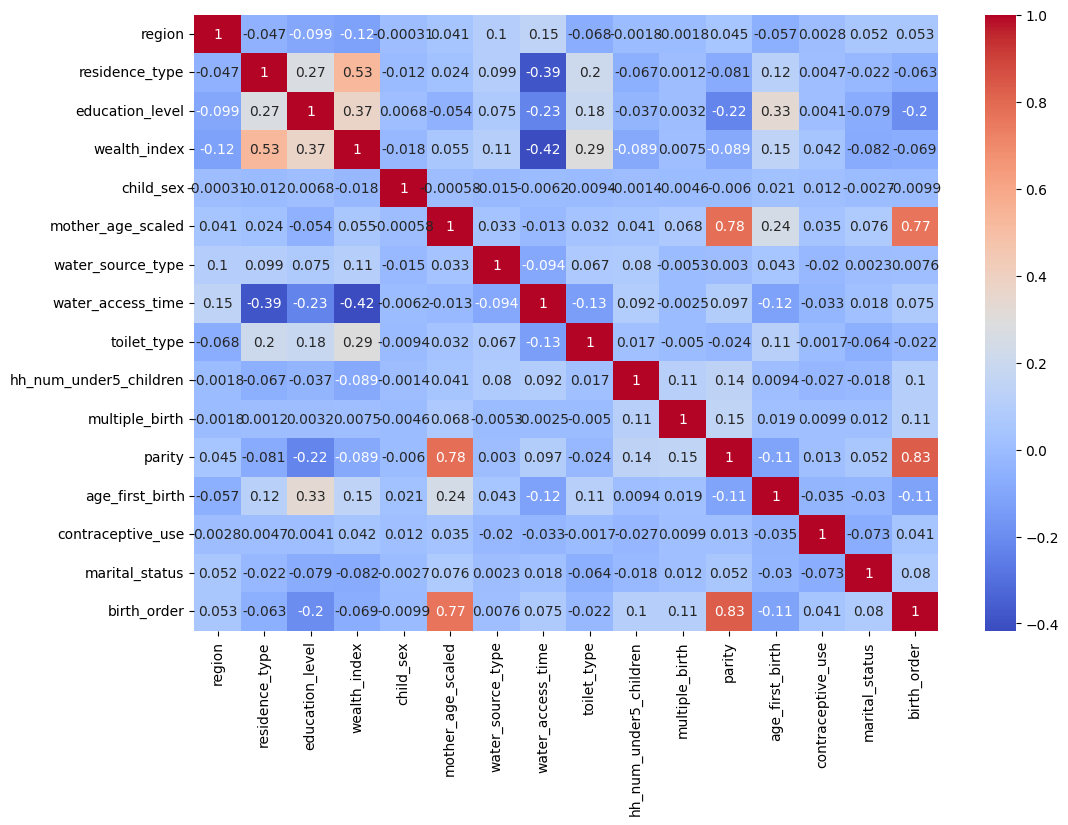

In [306]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.show()

Data split into training and testing sets successfully!
X_train shape: (9849, 16)
X_test shape: (2463, 16)
y_train shape: (9849,)
y_test shape: (2463,)

Features selected by RFE (Top 10):
['region', 'education_level', 'wealth_index', 'mother_age_scaled', 'water_access_time', 'toilet_type', 'hh_num_under5_children', 'parity', 'age_first_birth', 'marital_status']
Number of selected features: 10

X_train_selected shape: (9849, 10)
X_test_selected shape: (2463, 10)

Feature Rankings (RFE):
|                        |   0 |
|:-----------------------|----:|
| region                 |   1 |
| education_level        |   1 |
| wealth_index           |   1 |
| mother_age_scaled      |   1 |
| water_access_time      |   1 |
| parity                 |   1 |
| hh_num_under5_children |   1 |
| toilet_type            |   1 |
| marital_status         |   1 |
| age_first_birth        |   1 |
| birth_order            |   2 |
| child_sex              |   3 |
| contraceptive_use      |   4 |
| multiple_bir

/tmp/ipykernel_8223/2425254274.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_ranking.values, y=feature_ranking.index, palette="viridis")


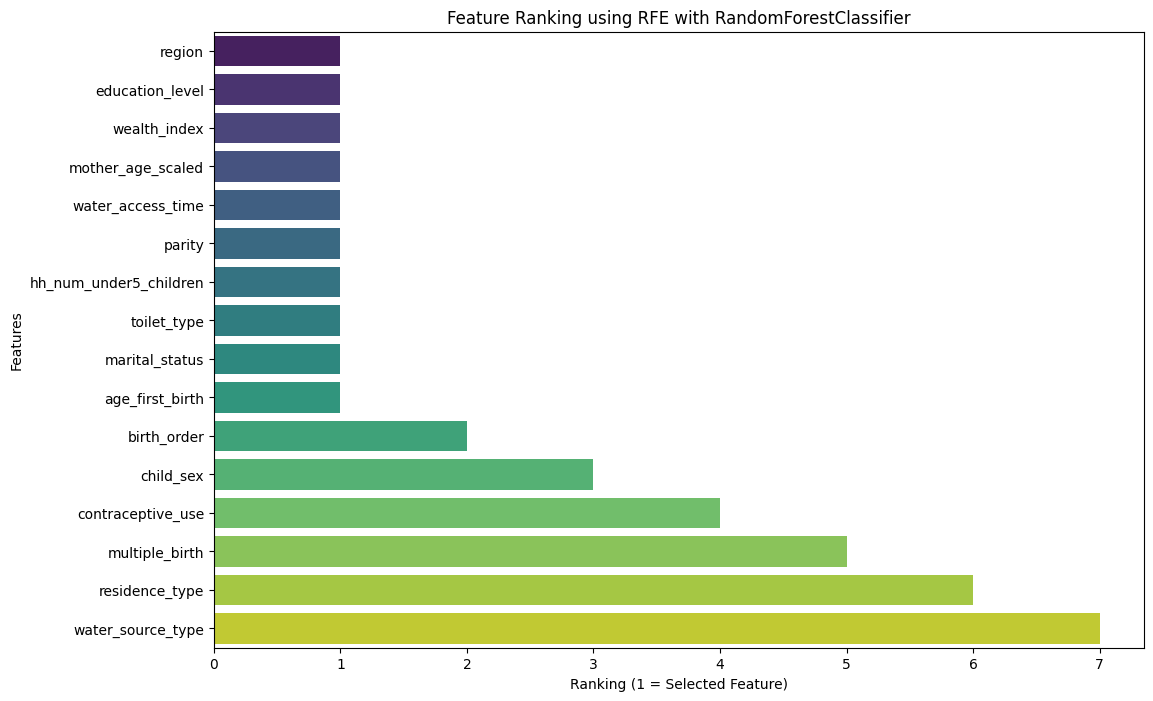

In [307]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split into training and testing sets successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Initialize RFE to select top 10 features
rfe = RFE(estimator=rfc, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[rfe.support_].tolist()

# Filter X_train and X_test to include only the selected top 10 features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("\nFeatures selected by RFE (Top 10):")
print(selected_features)
print(f"Number of selected features: {len(selected_features)}")

print(f"\nX_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

# Get feature ranking (1 = selected)
feature_ranking = pd.Series(rfe.ranking_, index=X_train.columns).sort_values()
print("\nFeature Rankings (RFE):")
print(feature_ranking.to_markdown())

# Visualize feature rankings
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_ranking.values, y=feature_ranking.index, palette="viridis")
plt.title('Feature Ranking using RFE with RandomForestClassifier')
plt.xlabel('Ranking (1 = Selected Feature)')
plt.ylabel('Features')
plt.show()

Class distribution BEFORE SMOTE + Tomek:
|   child_survival_status |   count |
|------------------------:|--------:|
|                       0 |    9499 |
|                       1 |     350 |


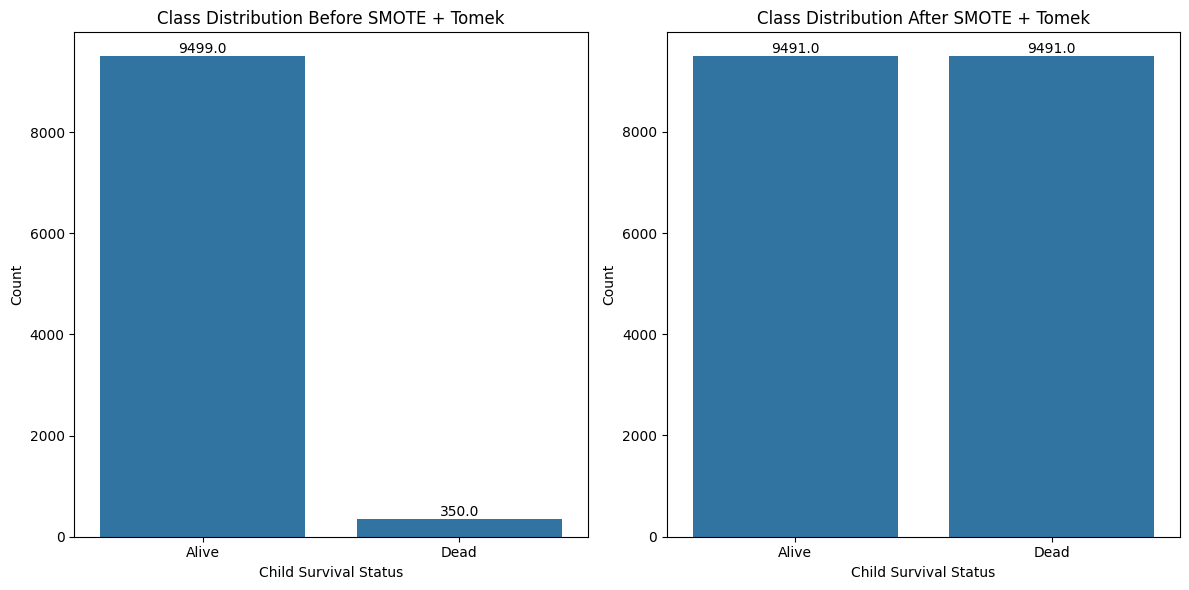


Class distribution AFTER SMOTE + Tomek:
|   child_survival_status |   count |
|------------------------:|--------:|
|                       0 |    9491 |
|                       1 |    9491 |

Shape of X_train before SMOTE + Tomek: (9849, 10)
Shape of y_train before SMOTE + Tomek: (9849,)
Shape of X_train after SMOTE + Tomek: (18982, 10)
Shape of y_train after SMOTE + Tomek: (18982,)


In [308]:
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns

# Map numeric labels to meaningful class names for plotting
label_mapping = {0: 'Alive', 1: 'Dead'}

# Visualize class distribution BEFORE SMOTE + Tomek
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train.map(label_mapping))
plt.title('Class Distribution Before SMOTE + Tomek')
plt.xlabel('Child Survival Status')
plt.ylabel('Count')

# Add value labels on each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom')

print("Class distribution BEFORE SMOTE + Tomek:")
print(y_train.value_counts().to_markdown())

# Apply SMOTE + Tomek to the training data
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_selected, y_train)

# Visualize class distribution AFTER SMOTE + Tomek
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_resampled.map(label_mapping))
plt.title('Class Distribution After SMOTE + Tomek')
plt.xlabel('Child Survival Status')
plt.ylabel('Count')

# Add value labels on each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nClass distribution AFTER SMOTE + Tomek:")
print(y_train_resampled.value_counts().to_markdown())

print(f"\nShape of X_train before SMOTE + Tomek: {X_train_selected.shape}")
print(f"Shape of y_train before SMOTE + Tomek: {y_train.shape}")
print(f"Shape of X_train after SMOTE + Tomek: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE + Tomek: {y_train_resampled.shape}")

Top 10 features selected by RFE:
['region', 'education_level', 'wealth_index', 'mother_age_scaled', 'water_access_time', 'toilet_type', 'hh_num_under5_children', 'parity', 'age_first_birth', 'marital_status']


/tmp/ipykernel_8223/1681579048.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, pd.DataFrame([{
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:12:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 350, number of negative: 9499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 67
[LightGBM] [Info] Number of data points in the train set: 9849, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035537 -> initscore=-3.301009
[LightGBM] [Info] Start training from score -3.301009


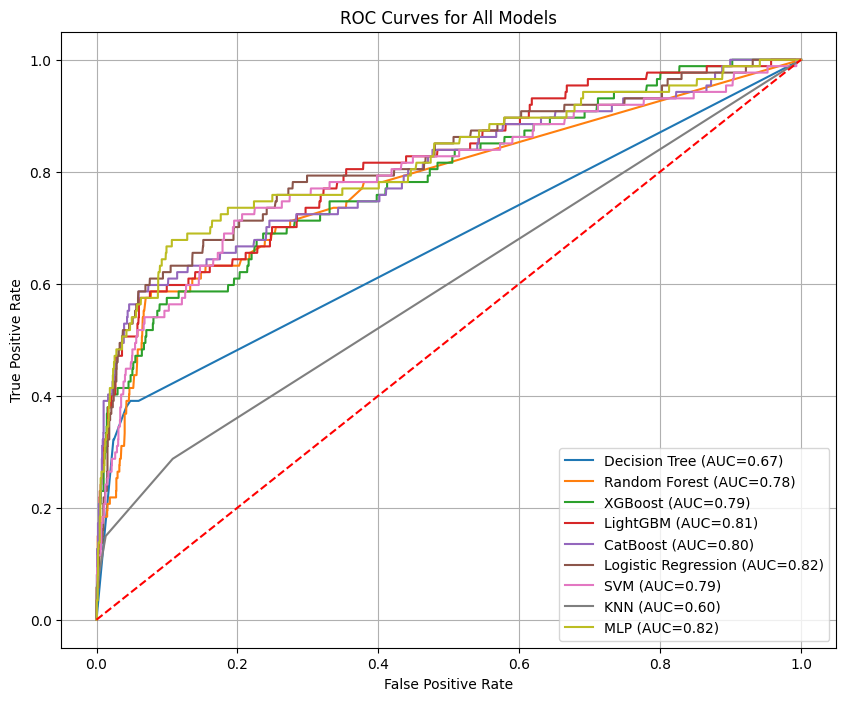

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,MLP,0.965895,0.560000,0.160920,0.250000,0.818806
1,Logistic Regression,0.801462,0.113462,0.678161,0.194399,0.816493
2,LightGBM,0.966301,0.545455,0.275862,0.366412,0.812473
3,CatBoost,0.966707,0.564103,0.252874,0.349206,0.799944
4,SVM,0.819732,0.121019,0.655172,0.204301,0.793829
5,XGBoost,0.963865,0.476190,0.229885,0.310078,0.788203
6,Random Forest,0.945189,0.244681,0.264368,0.254144,0.778000
7,Decision Tree,0.952091,0.321839,0.321839,0.321839,0.670897
8,KNN,0.966301,0.833333,0.057471,0.107527,0.596148


In [313]:
# -------------------------------
# Import Libraries
# -------------------------------
!pip install catboost --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Feature Selection with RFE
# -------------------------------
rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfe = RFE(estimator=rfc, n_features_to_select=10)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Top 10 features selected by RFE:")
print(selected_features)

# -------------------------------
# Optional: Resampling (if needed)
# -------------------------------
# Example: SMOTE or any oversampling technique
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)
# For simplicity, we use original X_train_selected
X_train_resampled, y_train_resampled = X_train_selected, y_train

# -------------------------------
# Define Models
# -------------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

# -------------------------------
# Evaluate All Models
# -------------------------------
metrics_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'])

plt.figure(figsize=(10, 8))  # ROC curves figure

for name, model in models.items():
    # Train
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_selected)
    y_pred_proba = model.predict_proba(X_test_selected)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_selected)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Append metrics to DataFrame using pd.concat
    metrics_df = pd.concat([metrics_df, pd.DataFrame([{
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC AUC': roc_auc
    }])], ignore_index=True)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')

# Plot ROC diagonal
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Display Metrics Table
# -------------------------------
metrics_df = metrics_df.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)
metrics_df